# Import libraries

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [157]:
import matplotlib.dates

In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [49]:
import datetime

In [ ]:
import seaborn as sns

# Load data

In [4]:
data = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Train.csv')
riders = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Riders.csv')
test_data = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/Test.csv')

In [123]:
#data_merge = pd.read_csv('C:/Users/piala/Documents/Github/regression_predict/data_merge.csv')

# Merge deliveries and riders data

In [192]:
data_merge = pd.merge(data, riders, how='left', left_on=['Rider Id'], right_on=['Rider Id'])

# Encode independent categorical variables

In [194]:
#Make User Id column numeric
a = data_merge['User Id'].str.split('User_Id_', n=1, expand = True)
data_merge['User Id (num)'] = a[1]
data_merge['User Id (num)'] = pd.to_numeric(data_merge['User Id (num)'])

In [195]:
#Make Rider Id column numeric
a = data_merge['Rider Id'].str.split('Rider_Id_', n=1, expand = True)
data_merge['Rider Id (num)'] = a[1]
data_merge['Rider Id (num)'] = pd.to_numeric(data_merge['Rider Id (num)'])

In [196]:
#One hot encode 'Personal or Business' columns
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), ['Personal or Business'])], remainder='passthrough')
X = pd.DataFrame(ct.fit_transform(data_merge))
data_merge['Business'] = X[0]
data_merge['Personal'] = X[1]

In [197]:
#Remove unnecessary columns
#data_merge.pop('Order No')
data_merge.pop('Vehicle Type')
data_merge.pop('Precipitation in millimeters')
data_merge.pop('User Id')
data_merge.pop('Rider Id')
data_merge.pop('Personal or Business')

0        Business
1        Personal
2        Business
3        Business
4        Personal
           ...   
21196    Personal
21197    Business
21198    Business
21199    Personal
21200    Business
Name: Personal or Business, Length: 21201, dtype: object

# Dealing with time columns
1. Transform to timestamps
2. Calculate time intervals between all time columns. Aim is to get a numeric value that can be tested for collinearity, 
    may act as a calculated value for the model
3. Check for any negative values (eg. impossible for a confirmation to happen before an order is placed)

In [198]:
#Transform time columns into 24 hour format
data_merge['Placement - Time'] = pd.to_datetime(data_merge['Placement - Time'], format='%I:%M:%S %p')
data_merge['Confirmation - Time'] = pd.to_datetime(data_merge['Confirmation - Time'], format='%I:%M:%S %p')
data_merge['Arrival at Pickup - Time'] = pd.to_datetime(data_merge['Arrival at Pickup - Time'], format='%I:%M:%S %p')
data_merge['Pickup - Time'] = pd.to_datetime(data_merge['Pickup - Time'], format='%I:%M:%S %p')
data_merge['Arrival at Destination - Time'] = pd.to_datetime(data_merge['Arrival at Destination - Time'], format='%I:%M:%S %p')

In [199]:
#Calculate differences between all time columns
difference0 = (data_merge['Confirmation - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]')
difference1 = (data_merge['Arrival at Pickup - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]')
difference2 = (data_merge['Pickup - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]')
difference3 = (data_merge['Arrival at Destination - Time'] - data_merge['Placement - Time']).astype('timedelta64[s]')
difference4 = (data_merge['Arrival at Pickup - Time'] - data_merge['Confirmation - Time']).astype('timedelta64[s]')
difference5 = (data_merge['Pickup - Time'] - data_merge['Confirmation - Time']).astype('timedelta64[s]')
difference6 = (data_merge['Arrival at Destination - Time'] - data_merge['Confirmation - Time']).astype('timedelta64[s]')
difference7 = (data_merge['Pickup - Time'] - data_merge['Arrival at Pickup - Time']).astype('timedelta64[s]')
difference8 = (data_merge['Arrival at Destination - Time'] - data_merge['Arrival at Pickup - Time']).astype('timedelta64[s]')
difference9 = (data_merge['Arrival at Destination - Time'] - data_merge['Pickup - Time']).astype('timedelta64[s]')

In [200]:
#Change intervals to integers for plotting
difference0 = difference0.astype(np.int64)
difference1 = difference1.astype(np.int64)
difference2 = difference2.astype(np.int64)
difference3 = difference3.astype(np.int64)
difference4 = difference4.astype(np.int64)
difference5 = difference5.astype(np.int64)
difference6 = difference6.astype(np.int64)
difference7 = difference7.astype(np.int64)
difference8 = difference8.astype(np.int64)
difference9 = difference9.astype(np.int64)

In [201]:
#Add time difference columns to data_merge for EDA and visualisations
data_merge['Con - Pl'] = difference0
data_merge['Arr P - Pl'] = difference1
data_merge['P - Pl'] = difference2
data_merge['Dest - Pl'] = difference3
data_merge['Arr P - Con'] = difference4
data_merge['P - Con'] = difference5
data_merge['Dest - Con'] = difference6
data_merge['P - Arr P'] = difference7
data_merge['Dest - Arr P'] = difference8
data_merge['Dest - P'] = difference9

In [203]:
data_merge.set_index('Order No')

,Platform Type,Placement - Day of Month,Placement - Weekday (Mo = 1),Placement - Time,Confirmation - Day of Month,Confirmation - Weekday (Mo = 1),Confirmation - Time,Arrival at Pickup - Day of Month,Arrival at Pickup - Weekday (Mo = 1),Arrival at Pickup - Time,...,Con - Pl,Arr P - Pl,P - Pl,Dest - Pl,Arr P - Con,P - Con,Dest - Con,P - Arr P,Dest - Arr P,Dest - P
Order No,,,,,,,,,,,,,,,,,,,,,
Order_No_4211,3,9,5,1900-01-01 09:35:46,9,5,1900-01-01 09:40:10,9,5,1900-01-01 10:04:47,...,264,1741,3104,3849,1477,2840,3585,1363,2108,745
Order_No_25375,3,12,5,1900-01-01 11:16:16,12,5,1900-01-01 11:23:21,12,5,1900-01-01 11:40:22,...,425,1446,1673,3666,1021,1248,3241,227,2220,1993
Order_No_1899,3,30,2,1900-01-01 12:39:25,30,2,1900-01-01 12:42:44,30,2,1900-01-01 12:49:34,...,199,609,818,1273,410,619,1074,209,664,455
Order_No_9336,3,15,5,1900-01-01 09:25:34,15,5,1900-01-01 09:26:05,15,5,1900-01-01 09:37:56,...,31,742,1052,2393,711,1021,2362,310,1651,1341
Order_No_27883,1,13,1,1900-01-01 09:55:18,13,1,1900-01-01 09:56:18,13,1,1900-01-01 10:03:53,...,60,515,605,1819,455,545,1759,90,1304,1214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Order_No_8834,3,20,3,1900-01-01 15:54:38,20,3,1900-01-01 15:55:09,20,3,1900-01-01 15:58:49,...,31,251,1530,1539,220,1499,1508,1279,1288,9
Order_No_22892,3,13,6,1900-01-01 10:13:34,13,6,1900-01-01 10:13:41,13,6,1900-01-01 10:20:04,...,7,390,1193,1963,383,1186,1956,803,1573,770
Order_No_2831,3,7,4,1900-01-01 17:06:16,7,4,1900-01-01 17:07:09,7,4,1900-01-01 17:30:17,...,53,1441,2676,5629,1388,2623,5576,1235,4188,2953


In [210]:
print(sum(data_merge['Con - Pl'] < 0))
print(sum(data_merge['Arr P - Pl'] < 0))
print(sum(data_merge['P - Pl'] < 0))
print(sum(data_merge['Dest - Pl'] < 0))
print(sum(data_merge['Arr P - Con'] < 0))
print(sum(data_merge['P - Con'] < 0))
print(sum(data_merge['Dest - Con'] < 0))
print(sum(data_merge['P - Arr P'] < 0))
print(sum(data_merge['Dest - Arr P'] < 0))
print(sum(data_merge['Dest - P'] < 0))
print(sum(data_merge['Time from Pickup to Arrival'] < 0))

0
0
0
0
0
0
0
0
0
0
0


In [211]:
#Drop rows that has negative time intervals (eg. not possible for the confirmation to happen before the order is placed)
data_merge = data_merge.drop(data_merge[data_merge['Con - Pl'] < 0].index)
print(len(data_merge)) #6 rows dropped

#Double check other time columns
print(sum(data_merge['Con - Pl'] < 0))
print(sum(data_merge['Arr P - Pl'] < 0))
print(sum(data_merge['P - Pl'] < 0))
print(sum(data_merge['Dest - Pl'] < 0))
print(sum(data_merge['Arr P - Con'] < 0))
print(sum(data_merge['P - Con'] < 0))
print(sum(data_merge['Dest - Con'] < 0))
print(sum(data_merge['P - Arr P'] < 0))
print(sum(data_merge['Dest - Arr P'] < 0))
print(sum(data_merge['Dest - P'] < 0))
print(sum(data_merge['Time from Pickup to Arrival'] < 0))

21195


In [134]:
#Change datetime columns to timestamps
#data_merge['Placement - Time'] = pd.Series([val.time() for val in data_merge['Placement - Time']])
#data_merge['Confirmation - Time'] = pd.Series([val.time() for val in data_merge['Confirmation - Time']])
#data_merge['Arrival at Pickup - Time'] = pd.Series([val.time() for val in data_merge['Arrival at Pickup - Time']])
#data_merge['Pickup - Time'] = pd.Series([val.time() for val in data_merge['Pickup - Time']])
#data_merge['Arrival at Destination - Time'] = pd.Series([val.time() for val in data_merge['Arrival at Destination - Time']])

In [ ]:
#Plot time intervals against each other to determine relationships

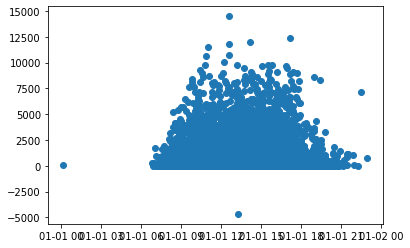

In [178]:
dates = matplotlib.dates.date2num(data_merge['Confirmation - Time'])
matplotlib.pyplot.plot_date(dates, data_merge['Con - Pl'])

In [135]:
#Move dependent variable to the end
data_merge['Time from Pickup to Arrival'] = data_merge.pop('Time from Pickup to Arrival')

In [179]:
data_merge.to_csv('data_merge.csv')

# Dealing with latitude and longitude columns
1. Convert to geohash values, these can then be encoded (Geohash package)
2. Troubleshoot accuracy parameter, need to reverse transform as well to ensure that the same coordinates are returned.
3. Consider UTM transformation (may not be the most accurate because works best with elevation value, small error margin though)

# EDA

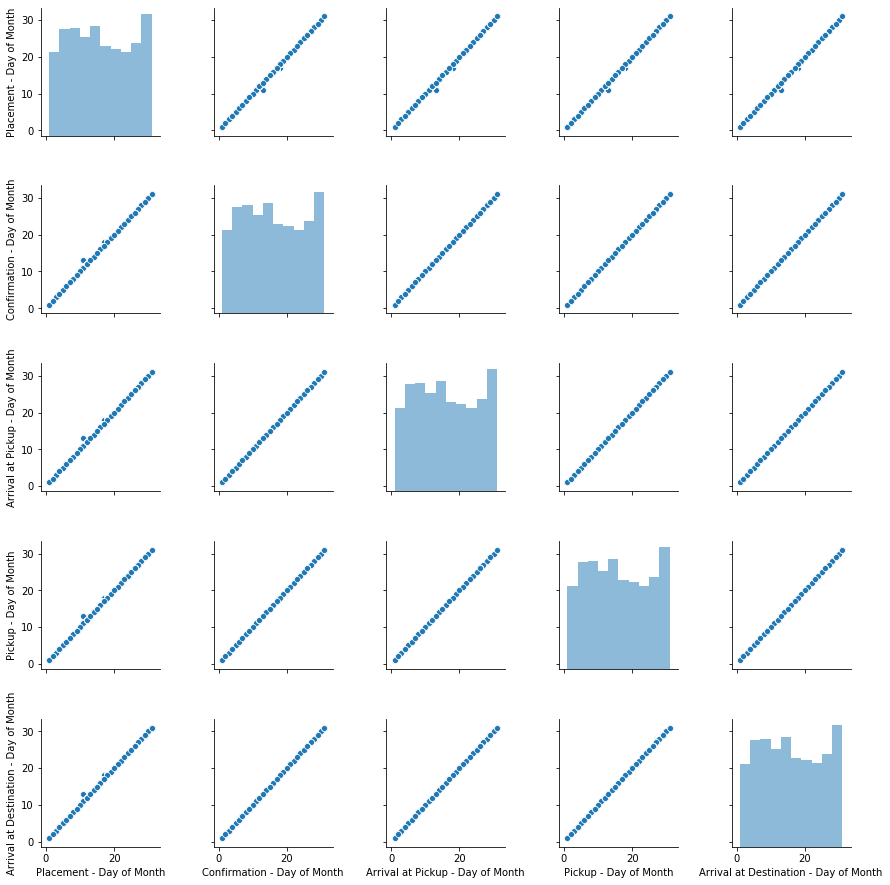

<Figure size 432x288 with 0 Axes>

In [137]:
sns.pairplot(data=data_merge,
        vars=['Placement - Day of Month', 'Confirmation - Day of Month', 'Arrival at Pickup - Day of Month', 'Pickup - Day of Month', 'Arrival at Destination - Day of Month'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

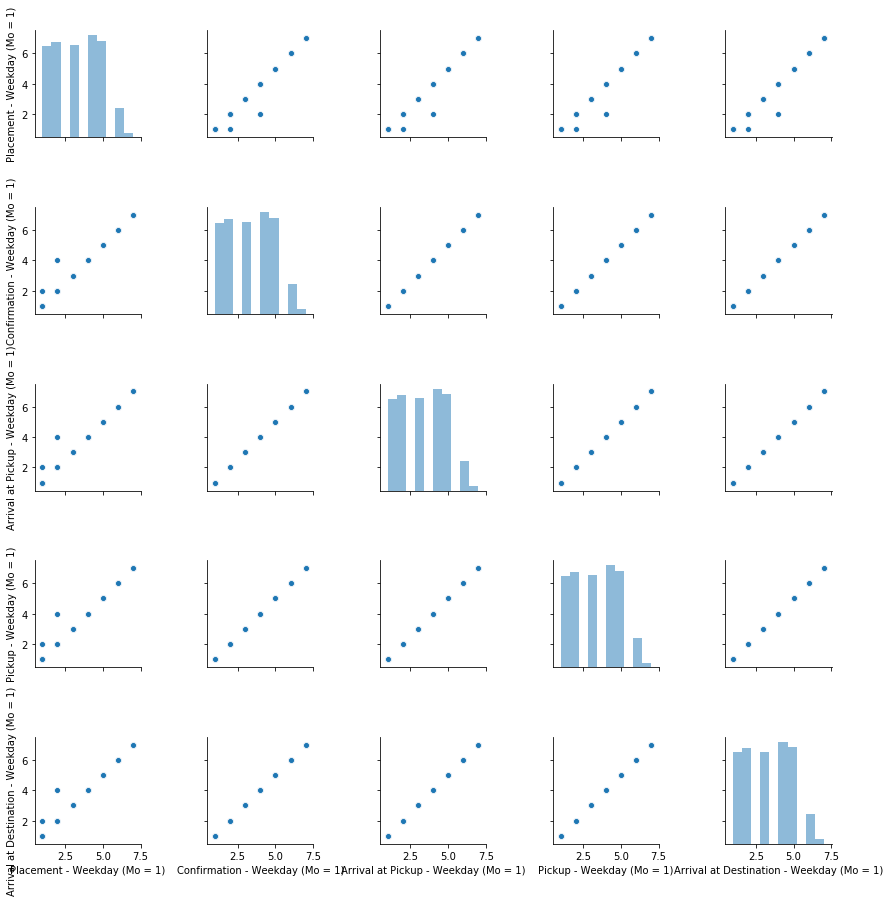

<Figure size 432x288 with 0 Axes>

In [138]:
sns.pairplot(data=data_merge,
        vars=['Placement - Weekday (Mo = 1)', 'Confirmation - Weekday (Mo = 1)', 'Arrival at Pickup - Weekday (Mo = 1)', 'Pickup - Weekday (Mo = 1)', 'Arrival at Destination - Weekday (Mo = 1)'],
        kind='scatter',
        palette='RdBu',
        diag_kws={'alpha':.5})

plt.show()
plt.clf()

# Suggestion: 
Keep Pickup 'Day of Month' and 'Weekday columns', remove others because clear display of multicollinearity apparent.
Choose Pickup because it is the most directly-related to drop-off time.

In [139]:
#Remove unnecessary columns
data_merge.pop('Placement - Weekday (Mo = 1)')
data_merge.pop('Confirmation - Weekday (Mo = 1)')
data_merge.pop('Arrival at Pickup - Weekday (Mo = 1)')
data_merge.pop('Pickup - Weekday (Mo = 1)')
data_merge.pop('Placement - Day of Month')
data_merge.pop('Confirmation - Day of Month')
data_merge.pop('Arrival at Pickup - Day of Month')
data_merge.pop('Pickup - Day of Month')
data_merge.head()

,Platform Type,Placement - Time,Confirmation - Time,Arrival at Pickup - Time,Pickup - Time,Arrival at Destination - Day of Month,Arrival at Destination - Weekday (Mo = 1),Arrival at Destination - Time,Distance (KM),Temperature,...,Arr P - Pl,P - Pl,Dest - Pl,Arr P - Con,P - Con,Dest - Con,P - Arr P,Dest - Arr P,Dest - P,Time from Pickup to Arrival
0,3,09:35:46,09:40:10,10:04:47,10:27:30,9,5,10:39:55,4,20.4,...,1741.0,3104.0,3849.0,1477.0,2840.0,3585.0,1363.0,2108.0,745.0,745
1,3,11:16:16,11:23:21,11:40:22,11:44:09,12,5,12:17:22,16,26.4,...,1446.0,1673.0,3666.0,1021.0,1248.0,3241.0,227.0,2220.0,1993.0,1993
2,3,12:39:25,12:42:44,12:49:34,12:53:03,30,2,13:00:38,3,NaN,...,609.0,818.0,1273.0,410.0,619.0,1074.0,209.0,664.0,455.0,455
3,3,09:25:34,09:26:05,09:37:56,09:43:06,15,5,10:05:27,9,19.2,...,742.0,1052.0,2393.0,711.0,1021.0,2362.0,310.0,1651.0,1341.0,1341
4,1,09:55:18,09:56:18,10:03:53,10:05:23,13,1,10:25:37,9,15.4,...,515.0,605.0,1819.0,455.0,545.0,1759.0,90.0,1304.0,1214.0,1214


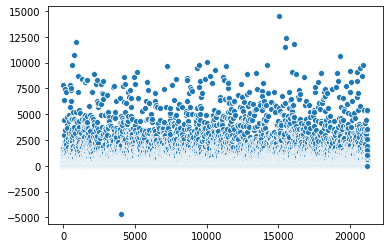

In [99]:
sns.scatterplot(data=test['Con - Pl'])

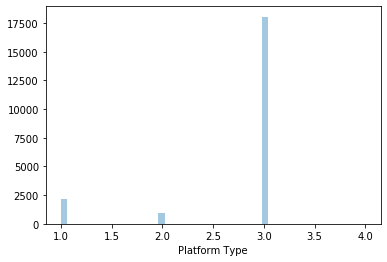

In [46]:
a = sns.distplot(data_merge['Platform Type'], kde=False)
plt.show()

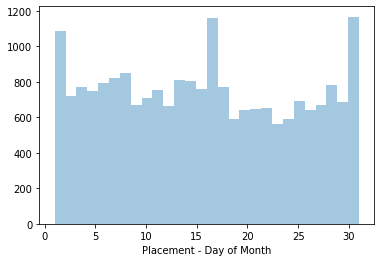

In [47]:
a = sns.distplot(data_merge['Placement - Day of Month'], kde=False)
plt.show()

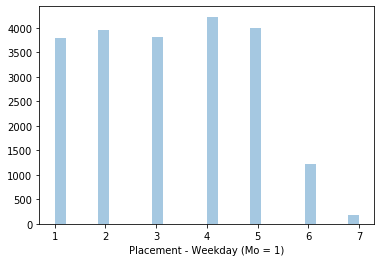

In [48]:
a = sns.distplot(data_merge['Placement - Weekday (Mo = 1)'], kde=False)
plt.show()

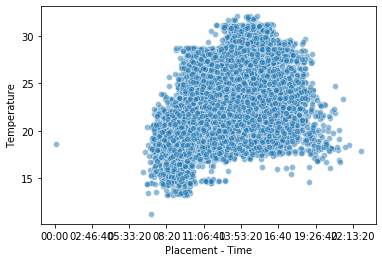

In [49]:
a = sns.scatterplot(data_merge['Placement - Time'], data_merge['Temperature'], alpha=0.5)
plt.show()

(21201, 31)

# Split the training set into training and validation set
(enable us to evaluate our model because we don't have the ground truths of the test set)

In [28]:
#Create the matrix of features.
X = data_merge.iloc[:, :-1].values #numpy array
y = dataset.iloc[:, -1].values #numpy array

[['Order_No_4211' 'User_Id_633' 'Bike' ... 1309 13.8 549]
 ['Order_No_25375' 'User_Id_2285' 'Bike' ... 339 13.6 69]
 ['Order_No_1899' 'User_Id_265' 'Bike' ... 242 12.5 114]
 ...
 ['Order_No_2831' 'User_Id_2956' 'Bike' ... 473 13.8 29]
 ['Order_No_6174' 'User_Id_2524' 'Bike' ... 1821 14.0 1101]
 ['Order_No_9836' 'User_Id_718' 'Bike' ... 286 13.6 70]]


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

NameError: name 'y' is not defined

# Missing data

# Encode categorical data
(Check dummy variable trap, only include n-1 dummy variables for every case where a dummy variable is necessary)

# Check assumptions of linear regression:
1. Linearity
2. Homoscedasticity
3. Multivariate normality
4. Independence of errors
5. Lack of multicolinearity

# Evaluation
Predicting the test set results
1. Plot predicted times from pick up to arrival
2. Select model with minimum mean square error in the test dataset